In [1]:
import sqlite3
import os
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from itertools import combinations
import re
from great_tables import GT, md, html

spark = SparkSession.builder.appName("FrequentItemsetMining").getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/10 13:53:37 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
conn = sqlite3.connect('tiktok_breadth_first.db')
cursor = conn.cursor()

In [3]:
query = """ 
SELECT hashtag_names 
FROM videos
JOIN follow_relations
ON follow_relations.from_username = videos.reposter_username
WHERE follow_relations.to_username = 'kamalahq'
"""

k_data = cursor.execute(query).fetchall()

In [4]:
query = """ 
SELECT hashtag_names 
FROM videos
JOIN follow_relations
ON follow_relations.from_username = videos.reposter_username
WHERE follow_relations.to_username = 'teamtrump'
"""

t_data = cursor.execute(query).fetchall()

In [5]:
k_df = spark.createDataFrame(k_data, ['raw_hash'])
t_df = spark.createDataFrame(t_data, ['raw_hash'])

In [6]:
k_df.show(5)

26/03/10 13:54:10 WARN TaskSetManager: Stage 0 contains a task of very large size (3143 KiB). The maximum recommended task size is 1000 KiB.


+--------------------+
|            raw_hash|
+--------------------+
|                 fyp|
|blancaevangelista...|
|foryou,Sleep,bedt...|
|cardsagainsthuman...|
|                    |
+--------------------+
only showing top 5 rows



In [7]:
# Spark-native hashtag preprocessing: split by commas, remove non-alphanumerics, lowercase, drop 'fyp'
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# Define stopwords
stop_hash = ['',]

# Use existing DataFrame `k_df` and ensure `raw_hash` is a string without nulls
_df = k_df.withColumn("raw_hash", F.coalesce(F.col("raw_hash").cast("string"), F.lit("")))

# Remove any characters except letters, digits, and commas
_cleaned = F.regexp_replace(F.col("raw_hash"), r"[^a-zA-Z0-9,]+", "")
_tokens = F.split(_cleaned, ",")

# Lowercase and filter out empty strings and 'fyp'
_lowered = F.transform(_tokens, lambda x: F.lower(x))
_filtered = F.filter(_lowered, lambda x: (x != "") & (~x.isin(stop_hash)))

# Add the cleaned list and a sequential id
w = Window.orderBy(F.monotonically_increasing_id())
k_df_clean = (
    _df
    .withColumn("clean_hash", _filtered)
    .withColumn("id", F.row_number().over(w))
)

_df = t_df.withColumn("raw_hash", F.coalesce(F.col("raw_hash").cast("string"), F.lit("")))

# Remove any characters except letters, digits, and commas
_cleaned = F.regexp_replace(F.col("raw_hash"), r"[^a-zA-Z0-9,]+", "")
_tokens = F.split(_cleaned, ",")

# Lowercase and filter out empty strings and 'fyp'
_lowered = F.transform(_tokens, lambda x: F.lower(x))
_filtered = F.filter(_lowered, lambda x: (x != "") & (~x.isin(stop_hash)))

# Add the cleaned list and a sequential id
w = Window.orderBy(F.monotonically_increasing_id())
t_df_clean = (
    _df
    .withColumn("clean_hash", _filtered)
    .withColumn("id", F.row_number().over(w))
)

# Show sample
t_df_clean.select("id", "raw_hash", "clean_hash").show(5, truncate=False)

26/03/10 13:54:12 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 13:54:12 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 13:54:12 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 13:54:12 WARN TaskSetManager: Stage 1 contains a task of very large size (1180 KiB). The maximum recommended task size is 1000 KiB.


+---+-------------------------------------------------------------+-------------------------------------------------------------------+
|id |raw_hash                                                     |clean_hash                                                         |
+---+-------------------------------------------------------------+-------------------------------------------------------------------+
|1  |overtime,fyp,trump2024                                       |[overtime, fyp, trump2024]                                         |
|2  |electrician,fyp,Viral                                        |[electrician, fyp, viral]                                          |
|3  |fy,construction,bluecollar,heat                              |[fy, construction, bluecollar, heat]                               |
|4  |fyp                                                          |[fyp]                                                              |
|5  |mgplumbing,TaylorSwift,dallastx,plumbersoft

In [8]:
k_df = k_df_clean.select('id', 'clean_hash')
t_df = t_df_clean.select('id', 'clean_hash')

In [9]:
k_df.show(5)

26/03/10 13:54:14 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 13:54:14 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 13:54:14 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 13:54:14 WARN TaskSetManager: Stage 3 contains a task of very large size (3143 KiB). The maximum recommended task size is 1000 KiB.


+---+--------------------+
| id|          clean_hash|
+---+--------------------+
|  1|               [fyp]|
|  2|[blancaevangelist...|
|  3|[foryou, sleep, b...|
|  4|[cardsagainsthuma...|
|  5|                  []|
+---+--------------------+
only showing top 5 rows



In [10]:
t_df.show(5)

26/03/10 13:54:19 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 13:54:19 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 13:54:19 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 13:54:19 WARN TaskSetManager: Stage 5 contains a task of very large size (1180 KiB). The maximum recommended task size is 1000 KiB.


+---+--------------------+
| id|          clean_hash|
+---+--------------------+
|  1|[overtime, fyp, t...|
|  2|[electrician, fyp...|
|  3|[fy, construction...|
|  4|               [fyp]|
|  5|[mgplumbing, tayl...|
+---+--------------------+
only showing top 5 rows



In [11]:
# support: minimum number s of posts an item needs to show up in
s_kamala = k_df.count() * 0.0005
L1 = (
    k_df.rdd.flatMap(lambda row: [((item,), 1) for item in row.clean_hash])
    .reduceByKey(lambda x, y: x + y)
    .filter(lambda x: x[1] >= s_kamala)
    .collect()
)

Lk_1_kamala = (dict(L1))

26/03/10 13:54:21 WARN TaskSetManager: Stage 7 contains a task of very large size (3143 KiB). The maximum recommended task size is 1000 KiB.
26/03/10 13:54:22 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 13:54:22 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 13:54:22 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 13:54:22 WARN TaskSetManager: Stage 10 contains a task of very large size (3143 KiB). The maximum recommended task size is 1000 KiB.
26/03/10 13:54:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 13:54:27 WARN WindowExec: No Partition Defined f

In [12]:
s_trump = t_df.count() * 0.0005

L1 = (
    t_df.rdd.flatMap(lambda row: [((item,), 1) for item in row.clean_hash])
    .reduceByKey(lambda x, y: x + y)
    .filter(lambda x: x[1] >= s_trump)
    .collect()
)

Lk_1_trump = (dict(L1))

26/03/10 13:54:40 WARN TaskSetManager: Stage 14 contains a task of very large size (1180 KiB). The maximum recommended task size is 1000 KiB.
26/03/10 13:54:41 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 13:54:41 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 13:54:41 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 13:54:41 WARN TaskSetManager: Stage 17 contains a task of very large size (1180 KiB). The maximum recommended task size is 1000 KiB.
26/03/10 13:54:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 13:54:42 WARN WindowExec: No Partition Defined 

In [13]:
Lk_1_kamala = {k: v for k, v in sorted(Lk_1_kamala.items(), key=lambda item: item[1], reverse=True)}
Lk_1_trump = {k: v for k, v in sorted(Lk_1_trump.items(), key=lambda item: item[1], reverse=True)}  

In [14]:
for item, count in Lk_1_trump.items():
    print(f"{item}: {count}")

('fyp',): 173251
('viral',): 56615
('foryou',): 31566
('foryoupage',): 27141
('edit',): 20826
('relatable',): 17846
('funny',): 13832
('trending',): 11553
('real',): 9506
('fy',): 9195
('fypviral',): 8293
('meme',): 8206
('xyzbca',): 7947
('capcut',): 7383
('football',): 6807
('viralvideo',): 6676
('blowthisup',): 5814
('fyppppppppppppppppppppppp',): 5319
('tiktok',): 5308
('trend',): 5149
('fypage',): 5033
('anime',): 4581
('love',): 4300
('fortnite',): 4124
('cat',): 4028
('goviral',): 4027
('motivation',): 3767
('pourtoi',): 3675
('nostalgia',): 3619
('music',): 3358
('catsoftiktok',): 3075
('dc',): 2956
('gaming',): 2833
('minecraft',): 2718
('footballtiktok',): 2677
('blowup',): 2645
('cars',): 2562
('school',): 2393
('christmas',): 2370
('sad',): 2351
('relationship',): 2319
('animeedit',): 2305
('bro',): 2201
('usa',): 2105
('roblox',): 2069
('viraltiktok',): 2052
('humour',): 2036
('memes',): 2026
('cats',): 1968
('gym',): 1963
('barcelona',): 1950
('dlaciebie',): 1931
('ufc',)

In [15]:
for item, count in Lk_1_kamala.items():
    print(f"{item}: {count}")

('fyp',): 608886
('viral',): 182853
('foryoupage',): 108229
('foryou',): 102823
('relatable',): 71432
('edit',): 70663
('funny',): 49064
('xyzbca',): 42608
('trending',): 40802
('fypviral',): 34137
('fy',): 25695
('fyppppppppppppppppppppppp',): 25198
('billieeilish',): 23102
('trend',): 22517
('real',): 22139
('blowthisup',): 20902
('strangerthings',): 20560
('viralvideo',): 20162
('meme',): 19493
('fypage',): 19416
('roblox',): 16666
('kpop',): 15670
('capcut',): 14947
('tiktok',): 13812
('school',): 13730
('blowup',): 12744
('music',): 12696
('katseye',): 12383
('anime',): 11368
('wlw',): 11151
('goviral',): 11020
('xybca',): 10024
('strangerthings5',): 9927
('nostalgia',): 9393
('love',): 9186
('aftereffects',): 8511
('edits',): 8282
('lyrics',): 8238
('billieeilishedits',): 8133
('christmas',): 7835
('fypp',): 7596
('cat',): 7365
('kpopfyp',): 7329
('animation',): 7252
('fnaf',): 7241
('xyzabc',): 7101
('relateable',): 6850
('fyppp',): 6772
('dance',): 6677
('parati',): 6671
('sad'

26/03/10 13:54:49 WARN TaskSetManager: Stage 21 contains a task of very large size (3143 KiB). The maximum recommended task size is 1000 KiB.
26/03/10 13:54:49 WARN TaskSetManager: Stage 24 contains a task of very large size (1180 KiB). The maximum recommended task size is 1000 KiB.


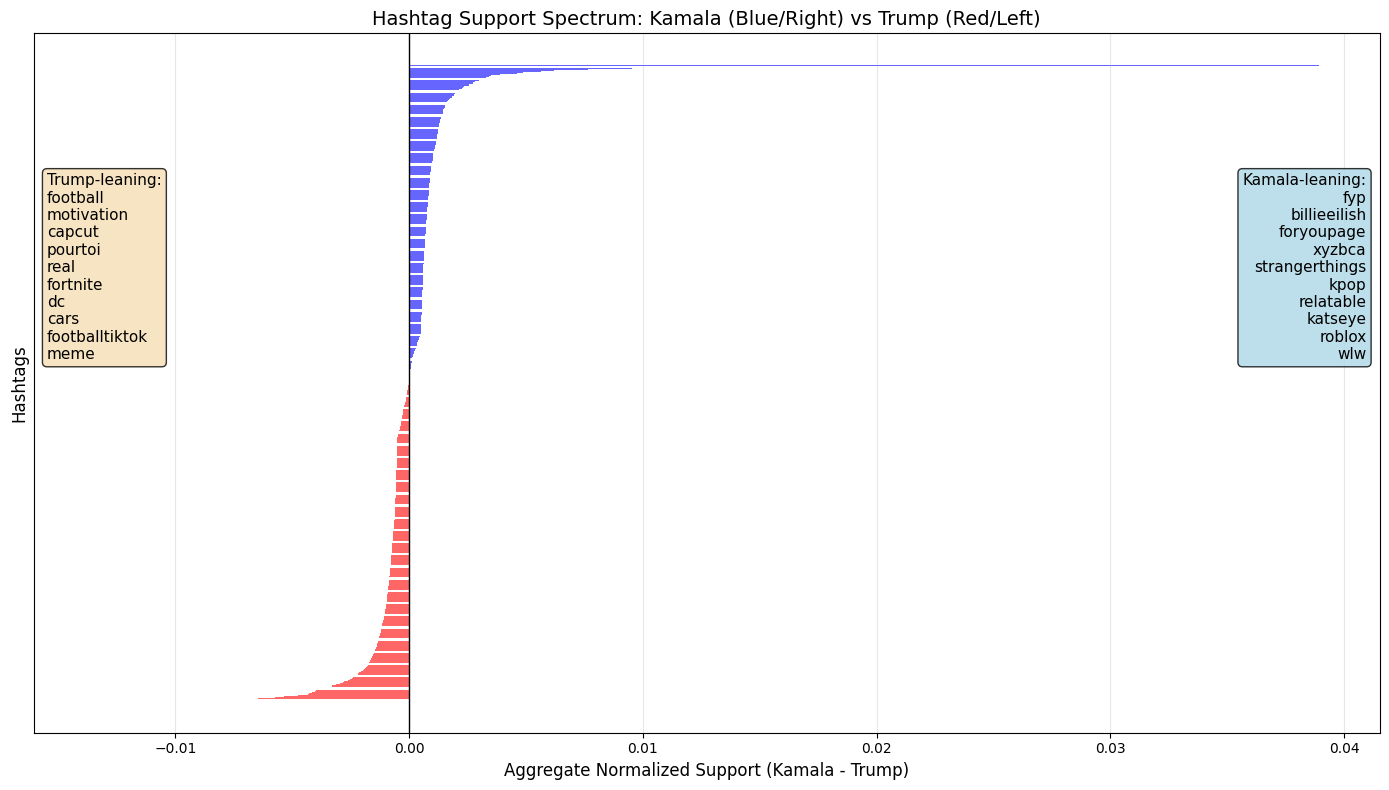

Total unique hashtags: 1324

Top 10 Kamala-leaning hashtags:
  fyp: 0.0389 (K: 0.4690, T: 0.4301)
  billieeilish: 0.0173 (K: 0.0178, T: 0.0005)
  foryoupage: 0.0160 (K: 0.0834, T: 0.0674)
  xyzbca: 0.0131 (K: 0.0328, T: 0.0197)
  strangerthings: 0.0113 (K: 0.0158, T: 0.0045)
  kpop: 0.0112 (K: 0.0121, T: 0.0009)
  relatable: 0.0107 (K: 0.0550, T: 0.0443)
  katseye: 0.0095 (K: 0.0095, T: 0.0000)
  roblox: 0.0077 (K: 0.0128, T: 0.0051)
  wlw: 0.0077 (K: 0.0086, T: 0.0009)

Top 10 Trump-leaning hashtags:
  football: -0.0134 (K: 0.0035, T: 0.0169)
  motivation: -0.0076 (K: 0.0018, T: 0.0094)
  capcut: -0.0068 (K: 0.0115, T: 0.0183)
  pourtoi: -0.0066 (K: 0.0025, T: 0.0091)
  real: -0.0065 (K: 0.0171, T: 0.0236)
  fortnite: -0.0065 (K: 0.0038, T: 0.0102)
  dc: -0.0058 (K: 0.0016, T: 0.0073)
  cars: -0.0057 (K: 0.0006, T: 0.0064)
  footballtiktok: -0.0054 (K: 0.0013, T: 0.0066)
  meme: -0.0054 (K: 0.0150, T: 0.0204)


In [16]:
import numpy as np

import matplotlib.pyplot as plt

# Get counts for normalization
k_count = k_df.count()
t_count = t_df.count()

# Calculate normalized support for each singleton
singleton_support = {}

for item, count in Lk_1_kamala.items():
    hashtag = item[0]
    k_norm = count / k_count
    t_norm = Lk_1_trump.get(item, 0) / t_count
    # Aggregate normalized support: positive for kamala, negative for trump
    aggregate = k_norm - t_norm
    singleton_support[hashtag] = {
        'kamala_support': k_norm,
        'trump_support': t_norm,
        'aggregate': aggregate
    }

# Add trump-only singletons
for item, count in Lk_1_trump.items():
    hashtag = item[0]
    if hashtag not in singleton_support:
        t_norm = count / t_count
        aggregate = -t_norm
        singleton_support[hashtag] = {
            'kamala_support': 0,
            'trump_support': t_norm,
            'aggregate': aggregate
        }

# Sort by aggregate support
sorted_items = sorted(singleton_support.items(), key=lambda x: x[1]['aggregate'])

# Create visualization
fig, ax = plt.subplots(figsize=(14, 8))

hashtags = [item[0] for item in sorted_items]
aggregates = [item[1]['aggregate'] for item in sorted_items]

# Color based on which side dominates
colors = ['red' if agg < 0 else 'blue' for agg in aggregates]

# Create bar chart
bars = ax.barh(range(len(hashtags)), aggregates, color=colors, alpha=0.6)
ax.set_yticks(range(len(hashtags)))
ax.set_yticklabels(hashtags, fontsize=9)

# Identify top 10 on each side
top_10_trump = set(range(10))  # Leftmost 10 (Trump)
top_10_kamala = set(range(len(hashtags) - 10, len(hashtags)))  # Rightmost 10 (Kamala)
label_indices = top_10_trump | top_10_kamala


# Left side (Trump) - top 10 terms
left_labels = [hashtags[i] for i in sorted(top_10_trump)]
left_text = "Trump-leaning:\n" + "\n".join(left_labels)

# Right side (Kamala) - top 10 terms
right_labels = [hashtags[i] for i in sorted(top_10_kamala, reverse=True)]
right_text = "Kamala-leaning:\n" + "\n".join(right_labels)

# Add text boxes to the left and right of the plot
ax.text(0.01, 0.8, left_text, transform=ax.transAxes, fontsize=11,
    verticalalignment='top', horizontalalignment='left',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.text(0.99, 0.8, right_text, transform=ax.transAxes, fontsize=11,
    verticalalignment='top', horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Aggregate Normalized Support (Kamala - Trump)', fontsize=12)
ax.set_ylabel('Hashtags', fontsize=12)
ax.set_title('Hashtag Support Spectrum: Kamala (Blue/Right) vs Trump (Red/Left)', fontsize=14)
ax.set_yticks([])
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total unique hashtags: {len(singleton_support)}")
print(f"\nTop 10 Kamala-leaning hashtags:")
for i in range(min(10, len(sorted_items))):
    idx = -(i+1)
    hashtag, data = sorted_items[idx]
    print(f"  {hashtag}: {data['aggregate']:.4f} (K: {data['kamala_support']:.4f}, T: {data['trump_support']:.4f})")

print(f"\nTop 10 Trump-leaning hashtags:")
for i in range(min(10, len(sorted_items))):
    hashtag, data = sorted_items[i]
    print(f"  {hashtag}: {data['aggregate']:.4f} (K: {data['kamala_support']:.4f}, T: {data['trump_support']:.4f})")

In [17]:
# Ensure each clean_hash array contains only unique hashtags
k_df = k_df.withColumn("clean_hash", F.array_distinct(F.col("clean_hash")))
t_df = t_df.withColumn("clean_hash", F.array_distinct(F.col("clean_hash")))

In [18]:
from pyspark.ml.fpm import FPGrowth

# FPGrowth requires the input column to be named 'items'

# Before running cell again: check to make sure all hashes are unique sets


fp_growth_k = FPGrowth(itemsCol="clean_hash", minSupport=(s_kamala / k_df.count()), minConfidence=0.8)
model_k = fp_growth_k.fit(k_df)

# Display frequent itemsets

print("Frequent Itemsets found by FP-Growth:")
model_k.freqItemsets.sort("freq", ascending=False).show()

# Display generated association rules
print("Association Rules found by FP-Growth:")
model_k.associationRules.sort("confidence", ascending=False).show()

26/03/10 13:54:55 WARN TaskSetManager: Stage 27 contains a task of very large size (3143 KiB). The maximum recommended task size is 1000 KiB.
26/03/10 13:54:55 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 13:54:55 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 13:54:55 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 13:54:55 WARN TaskSetManager: Stage 30 contains a task of very large size (3143 KiB). The maximum recommended task size is 1000 KiB.
26/03/10 13:55:01 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 13:55:01 WARN WindowExec: No Partition Defined 

Frequent Itemsets found by FP-Growth:


+--------------------+------+
|               items|  freq|
+--------------------+------+
|               [fyp]|566359|
|             [viral]|182440|
|        [viral, fyp]|145929|
|        [foryoupage]|107596|
|            [foryou]|102813|
|   [foryoupage, fyp]| 79035|
|       [foryou, fyp]| 76710|
|         [relatable]| 71414|
|              [edit]| 70663|
|    [relatable, fyp]| 50901|
|             [funny]| 49060|
|         [edit, fyp]| 45972|
|            [xyzbca]| 42607|
|          [trending]| 40802|
| [foryoupage, viral]| 34951|
|     [foryou, viral]| 34935|
|       [xyzbca, fyp]| 34156|
|          [fypviral]| 33898|
|[foryou, foryoupage]| 33866|
|        [funny, fyp]| 32722|
+--------------------+------+
only showing top 20 rows

Association Rules found by FP-Growth:


+--------------------+------------------+------------------+------------------+--------------------+
|          antecedent|        consequent|        confidence|              lift|             support|
+--------------------+------------------+------------------+------------------+--------------------+
|       [hmhas, edit]|    [billieeilish]|0.9925650557620818| 55.79313115830045|6.169307042791577E-4|
|[billieeilishedit...|    [billieeilish]|0.9898255813953488|55.639142407879866|5.245066287317184E-4|
|[billieeilishedit...|    [billieeilish]|0.9876265466816648| 55.51553234172856|6.762361527554312E-4|
|  [shortnsweet, fyp]|[sabrinacarpenter]|0.9874476987447699|253.17250325540198|5.453020457298922E-4|
|[billieeilishedit...|    [billieeilish]|0.9866045428072219|55.458084423448476|0.001304719866478...|
|[billieeilishedit...|    [billieeilish]|0.9851988899167438|55.379071188370126|8.202636704835243E-4|
|[billieeilishedit...|    [billieeilish]| 0.984789391575663| 55.35605285368224|0.0019447565

In [19]:
fp_growth_t = FPGrowth(itemsCol="clean_hash", minSupport=(s_trump / t_df.count()), minConfidence=0.8)
model_t = fp_growth_t.fit(t_df)

# Display frequent itemsets

print("Frequent Itemsets found by FP-Growth:")
model_t.freqItemsets.sort("freq", ascending=False).show()

# Display generated association rules
print("Association Rules found by FP-Growth:")
model_t.associationRules.sort("confidence", ascending=False).show()

26/03/10 13:55:30 WARN TaskSetManager: Stage 41 contains a task of very large size (1180 KiB). The maximum recommended task size is 1000 KiB.
26/03/10 13:55:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 13:55:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 13:55:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 13:55:30 WARN TaskSetManager: Stage 44 contains a task of very large size (1180 KiB). The maximum recommended task size is 1000 KiB.
26/03/10 13:55:32 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 13:55:32 WARN WindowExec: No Partition Defined 

Frequent Itemsets found by FP-Growth:


26/03/10 13:55:34 WARN TaskSetManager: Stage 49 contains a task of very large size (1180 KiB). The maximum recommended task size is 1000 KiB.


+--------------------+------+
|               items|  freq|
+--------------------+------+
|               [fyp]|162415|
|             [viral]| 56566|
|        [viral, fyp]| 44562|
|            [foryou]| 31560|
|        [foryoupage]| 27016|
|       [foryou, fyp]| 23189|
|              [edit]| 20826|
|   [foryoupage, fyp]| 20346|
|         [relatable]| 17844|
|             [funny]| 13830|
|    [relatable, fyp]| 12805|
|         [edit, fyp]| 12603|
|          [trending]| 11553|
|     [foryou, viral]| 10735|
|[foryoupage, foryou]|  9621|
|              [real]|  9506|
|                [fy]|  9192|
| [foryoupage, viral]|  9058|
|     [trending, fyp]|  8832|
|        [funny, fyp]|  8810|
+--------------------+------+
only showing top 20 rows

Association Rules found by FP-Growth:


+--------------------+-----------+------------------+------------------+--------------------+
|          antecedent| consequent|        confidence|              lift|             support|
+--------------------+-----------+------------------+------------------+--------------------+
|         [mattsmith]|[doctorwho]|0.9730941704035875|449.05119196215304|5.386473250078811E-4|
|[formulaone, form...|       [f1]|0.9715639810426541|228.89195144258753|5.088603761595191E-4|
|[trend, trending,...|      [fyp]|0.9691629955947136| 2.403952674126663|0.001092188124439...|
|[dexteredit, dext...|   [dexter]|0.9649122807017544|248.22830543792432|6.826175777749645E-4|
|[cars, foryoupage...|      [fyp]|0.9620853080568721| 2.386396880147151| 5.03895884684792E-4|
|[trend, trending,...|      [fyp]|0.9595959595959596| 2.380222195479407|7.074400351485997E-4|
|        [10thdoctor]|[doctorwho]|0.9595588235294118|442.80507125530625|6.478661374518755E-4|
|              [asap]|[asaprocky]|0.9565217391304348|433.947

In [20]:
import pandas as pd

# Calculate statistics for k_df
k_total_sets = k_df.count()
k_total_tokens = k_df.rdd.flatMap(lambda row: row.clean_hash).count()
k_unique_tokens = k_df.rdd.flatMap(lambda row: row.clean_hash).distinct().count()
k_top_5 = sorted(Lk_1_kamala.items(), key=lambda x: x[1], reverse=True)[:5]

# Calculate statistics for t_df
t_total_sets = t_df.count()
t_total_tokens = t_df.rdd.flatMap(lambda row: row.clean_hash).count()
t_unique_tokens = t_df.rdd.flatMap(lambda row: row.clean_hash).distinct().count()
t_top_5 = sorted(Lk_1_trump.items(), key=lambda x: x[1], reverse=True)[:5]

# Create summary table
stats_data = {
    'Metric': [
        'Total Sets',
        'Total Tokens',
        'Unique Tokens',
    ],
    'Harris': [
        k_total_sets,
        k_total_tokens,
        k_unique_tokens,
    ],
    'Trump': [
        t_total_sets,
        t_total_tokens,
        t_unique_tokens,
    ]
}

stats_df = pd.DataFrame(stats_data)
print(stats_df.to_string(index=False))
# Calculate average set length
k_avg_length = k_df.rdd.map(lambda row: len(row.clean_hash)).mean()
t_avg_length = t_df.rdd.map(lambda row: len(row.clean_hash)).mean()

# Add to stats_data
stats_data['Metric'].insert(3, 'Average Set Length')
stats_data['Harris'].insert(3, f"{k_avg_length:.2f}")
stats_data['Trump'].insert(3, f"{t_avg_length:.2f}")

stats_df = pd.DataFrame(stats_data)
print(stats_df.to_string(index=False))


26/03/10 13:55:41 WARN TaskSetManager: Stage 55 contains a task of very large size (3143 KiB). The maximum recommended task size is 1000 KiB.
26/03/10 13:55:41 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 13:55:41 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 13:55:41 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 13:55:41 WARN TaskSetManager: Stage 58 contains a task of very large size (3143 KiB). The maximum recommended task size is 1000 KiB.
26/03/10 13:55:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 13:55:46 WARN WindowExec: No Partition Defined 

       Metric  Harris   Trump
   Total Sets 1298363  402861
 Total Tokens 6259496 1870552
Unique Tokens  468933  227749


            Metric  Harris   Trump
        Total Sets 1298363  402861
      Total Tokens 6259496 1870552
     Unique Tokens  468933  227749
Average Set Length    4.82    4.64


In [21]:
basic_stats = GT(stats_df).tab_header(title='Corpus Overview: Harris vs. Trump')
basic_stats.save('viz/great_table_itemset_stats.png')

GT(_tbl_data=               Metric   Harris    Trump
0          Total Sets  1298363   402861
1        Total Tokens  6259496  1870552
2       Unique Tokens   468933   227749
3  Average Set Length     4.82     4.64, _body=<great_tables._gt_data.Body object at 0x7fb703282a10>, _boxhead=Boxhead([ColInfo(var='Metric', type=<ColInfoTypeEnum.default: 1>, column_label='Metric', column_align='left', column_width=None), ColInfo(var='Harris', type=<ColInfoTypeEnum.default: 1>, column_label='Harris', column_align='right', column_width=None), ColInfo(var='Trump', type=<ColInfoTypeEnum.default: 1>, column_label='Trump', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fb702c1a390>, _spanners=Spanners([]), _heading=Heading(title='Corpus Overview: Harris vs. Trump', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fb702eaa650>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fb70323c310>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7fb702fcac50>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), heading_background_color=OptionsInfo(scss=True, category='heading', type='value', value=None), heading_align=OptionsI

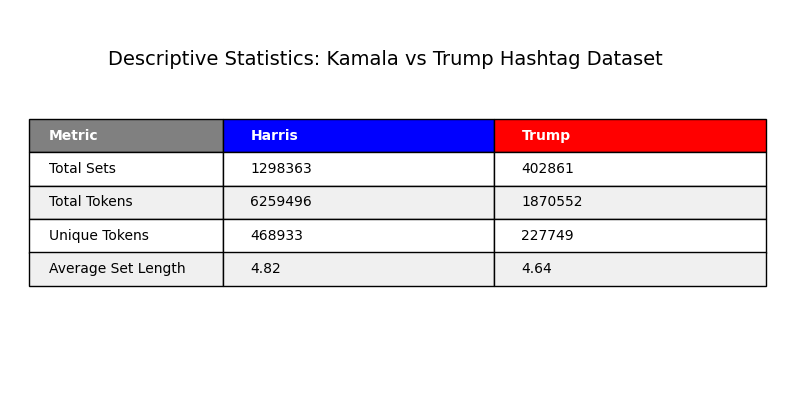

In [36]:

# Convert table to image
import matplotlib.pyplot as plt
from matplotlib.table import Table

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('tight')
ax.axis('off')

# Create table
table = ax.table(cellText=stats_df.values, colLabels=stats_df.columns, 
                 cellLoc='center', loc='center', colWidths=[0.25, 0.35, 0.35])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header
colors = ['grey', 'blue', 'red']
for i in range(len(stats_df.columns)):
    table[(0, i)].set_facecolor(colors[i])
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(stats_df) + 1):
    for j in range(len(stats_df.columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')
        else:
            table[(i, j)].set_facecolor('#ffffff')

# Add title
fig.suptitle('Descriptive Statistics: Kamala vs Trump Hashtag Dataset', fontsize=14, y=0.8)

# Left justify text in cells
for i in range(len(stats_df) + 1):
    for j in range(len(stats_df.columns)):
        table[(i, j)].set_text_props(ha='left')
        
plt.savefig('viz/descriptive_statistics_table_all_tokens.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
from PIL import Image, ImageDraw, ImageFont
from io import StringIO

# Get the association rules
rules_df = model_t.associationRules.sort("confidence", ascending=False)

# Convert to Pandas for easier plotting
rules_pd = rules_df.toPandas()

rules_pd = rules_pd[:100]

rules_pd['confidence'] = rules_pd['confidence'].apply(lambda x: round(x, 3))
rules_pd['lift'] = rules_pd['lift'].apply(lambda x: round(x, 3))
rules_pd['support'] = rules_pd['support'].apply(lambda x: round(x, 4))

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, len(rules_pd) * 0.5))
ax.axis('tight')
ax.axis('off')

# Create table
table = ax.table(cellText=rules_pd.values, 
                 colLabels=rules_pd.columns,
                 cellLoc='left',
                 loc='center')

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)  # Adjust cell height

# Save to PNG
plt.savefig('viz/trump_association_rules_all_tokens.png', bbox_inches='tight', dpi=300)
plt.close()

In [33]:
rules_pd = rules_pd[:30]
gt_t_rules = GT(rules_pd).tab_header(title='Trump Association Rules, High Confidence', subtitle='The top 30 highest confidence association rules')
gt_t_rules

GT(_tbl_data=                               antecedent   consequent  confidence     lift  \
0                             [mattsmith]  [doctorwho]       0.973  449.051   
1                  [formulaone, formula1]         [f1]       0.972  228.892   
2    [trend, trending, foryoupage, viral]        [fyp]       0.969    2.404   
3              [dexteredit, dextermorgan]     [dexter]       0.965  248.228   
4               [cars, foryoupage, viral]        [fyp]       0.962    2.386   
5        [trend, trending, foryou, viral]        [fyp]       0.960    2.380   
6                            [10thdoctor]  [doctorwho]       0.960  442.805   
7                                  [asap]  [asaprocky]       0.957  433.947   
8           [trend, trending, foryoupage]        [fyp]       0.952    2.362   
9      [trend, foryoupage, foryou, viral]        [fyp]       0.952    2.362   
10    [fypage, foryoupage, foryou, viral]        [fyp]       0.950    2.356   
11      [edit, foryoupage, foryou, viral]        [fyp]       0.949    2.354   
12             [love, foryoupage, foryou]        [fyp]       0.947    2.350   
13   [goviral, foryoupage, foryou, viral]        [fyp]       0.946    2.347   
14    [xyzbca, foryoupage, foryou, viral]        [fyp]       0.946    2.346   
15                        [ichigo, anime]     [bleach]       0.942  252.953   
16    [tiktok, foryoupage, foryou, viral]        [fyp]       0.941    2.335   
17              [trend, trending, foryou]        [fyp]       0.940    2.332   
18          [viralvideo, fypviral, viral]        [fyp]       0.939    2.330   
19     [funny, foryoupage, foryou, viral]        [fyp]       0.939    2.330   
20                           [dexteredit]     [dexter]       0.938  241.397   
21             [trend, foryoupage, viral]        [fyp]       0.938    2.327   
22  [trend, trending, foryoupage, foryou]        [fyp]       0.938    2.326   
23        [fy, foryoupage, foryou, viral]        [fyp]       0.937    2.325   
24              [love, foryoupage, viral]        [fyp]       0.937    2.324   
25            [fypage, viralvideo, viral]        [fyp]       0.936    2.323   
26       [fypage, fy, foryoupage, foryou]        [fyp]       0.935    2.320   
27                   [f1tiktok, formula1]         [f1]       0.934  220.058   
28                           [formulaone]         [f1]       0.933  219.709   
29                   [dextermorgan, edit]     [dexter]       0.932  239.691   

    support  
0    0.0005  
1    0.0005  
2    0.0011  
3    0.0007  
4    0.0005  
5    0.0007  
6    0.0006  
7    0.0005  
8    0.0013  
9    0.0009  
10   0.0008  
11   0.0011  
12   0.0009  
13   0.0006  
14   0.0010  
15   0.0009  
16   0.0009  
17   0.0010  
18   0.0008  
19   0.0010  
20   0.0010  
21   0.0019  
22   0.0006  
23   0.0017  
24   0.0007  
25   0.0007  
26   0.0005  
27   0.0006  
28   0.0006  
29   0.0006  , _body=<great_tables._gt_data.Body object at 0x7fb6c2b237d0>, _boxhead=Boxhead([ColInfo(var='antecedent', type=<ColInfoTypeEnum.default: 1>, column_label='antecedent', column_align='right', column_width=None), ColInfo(var='consequent', type=<ColInfoTypeEnum.default: 1>, column_label='consequent', column_align='right', column_width=None), ColInfo(var='confidence', type=<ColInfoTypeEnum.default: 1>, column_label='confidence', column_align='right', column_width=None), ColInfo(var='lift', type=<ColInfoTypeEnum.default: 1>, column_label='lift', column_align='right', column_width=None), ColInfo(var='support', type=<ColInfoTypeEnum.default: 1>, column_label='support', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fb6c0bc7310>, _spanners=Spanners([]), _heading=Heading(title='Trump Association Rules, High Confidence', subtitle='The top 30 highest confidence association rules', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fb6c2bd4e10>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7

In [34]:
gt_t_rules.save('viz/gt_trump_association_rules.png')

GT(_tbl_data=                               antecedent   consequent  confidence     lift  \
0                             [mattsmith]  [doctorwho]       0.973  449.051   
1                  [formulaone, formula1]         [f1]       0.972  228.892   
2    [trend, trending, foryoupage, viral]        [fyp]       0.969    2.404   
3              [dexteredit, dextermorgan]     [dexter]       0.965  248.228   
4               [cars, foryoupage, viral]        [fyp]       0.962    2.386   
5        [trend, trending, foryou, viral]        [fyp]       0.960    2.380   
6                            [10thdoctor]  [doctorwho]       0.960  442.805   
7                                  [asap]  [asaprocky]       0.957  433.947   
8           [trend, trending, foryoupage]        [fyp]       0.952    2.362   
9      [trend, foryoupage, foryou, viral]        [fyp]       0.952    2.362   
10    [fypage, foryoupage, foryou, viral]        [fyp]       0.950    2.356   
11      [edit, foryoupage, foryou, viral]        [fyp]       0.949    2.354   
12             [love, foryoupage, foryou]        [fyp]       0.947    2.350   
13   [goviral, foryoupage, foryou, viral]        [fyp]       0.946    2.347   
14    [xyzbca, foryoupage, foryou, viral]        [fyp]       0.946    2.346   
15                        [ichigo, anime]     [bleach]       0.942  252.953   
16    [tiktok, foryoupage, foryou, viral]        [fyp]       0.941    2.335   
17              [trend, trending, foryou]        [fyp]       0.940    2.332   
18          [viralvideo, fypviral, viral]        [fyp]       0.939    2.330   
19     [funny, foryoupage, foryou, viral]        [fyp]       0.939    2.330   
20                           [dexteredit]     [dexter]       0.938  241.397   
21             [trend, foryoupage, viral]        [fyp]       0.938    2.327   
22  [trend, trending, foryoupage, foryou]        [fyp]       0.938    2.326   
23        [fy, foryoupage, foryou, viral]        [fyp]       0.937    2.325   
24              [love, foryoupage, viral]        [fyp]       0.937    2.324   
25            [fypage, viralvideo, viral]        [fyp]       0.936    2.323   
26       [fypage, fy, foryoupage, foryou]        [fyp]       0.935    2.320   
27                   [f1tiktok, formula1]         [f1]       0.934  220.058   
28                           [formulaone]         [f1]       0.933  219.709   
29                   [dextermorgan, edit]     [dexter]       0.932  239.691   

    support  
0    0.0005  
1    0.0005  
2    0.0011  
3    0.0007  
4    0.0005  
5    0.0007  
6    0.0006  
7    0.0005  
8    0.0013  
9    0.0009  
10   0.0008  
11   0.0011  
12   0.0009  
13   0.0006  
14   0.0010  
15   0.0009  
16   0.0009  
17   0.0010  
18   0.0008  
19   0.0010  
20   0.0010  
21   0.0019  
22   0.0006  
23   0.0017  
24   0.0007  
25   0.0007  
26   0.0005  
27   0.0006  
28   0.0006  
29   0.0006  , _body=<great_tables._gt_data.Body object at 0x7fb6c2b237d0>, _boxhead=Boxhead([ColInfo(var='antecedent', type=<ColInfoTypeEnum.default: 1>, column_label='antecedent', column_align='right', column_width=None), ColInfo(var='consequent', type=<ColInfoTypeEnum.default: 1>, column_label='consequent', column_align='right', column_width=None), ColInfo(var='confidence', type=<ColInfoTypeEnum.default: 1>, column_label='confidence', column_align='right', column_width=None), ColInfo(var='lift', type=<ColInfoTypeEnum.default: 1>, column_label='lift', column_align='right', column_width=None), ColInfo(var='support', type=<ColInfoTypeEnum.default: 1>, column_label='support', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fb6c0bc7310>, _spanners=Spanners([]), _heading=Heading(title='Trump Association Rules, High Confidence', subtitle='The top 30 highest confidence association rules', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fb6c2bd4e10>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7

In [29]:
# Get the association rules
rules_df = model_k.associationRules.sort("confidence", ascending=False)

# Convert to Pandas for easier plotting
rules_pd = rules_df.toPandas()

rules_pd = rules_pd[:100]

rules_pd['confidence'] = rules_pd['confidence'].apply(lambda x: round(x, 3))
rules_pd['lift'] = rules_pd['lift'].apply(lambda x: round(x, 3))
rules_pd['support'] = rules_pd['support'].apply(lambda x: round(x, 4))

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, len(rules_pd) * 0.5))
ax.axis('tight')
ax.axis('off')

# Create table
table = ax.table(cellText=rules_pd.values, 
                 colLabels=rules_pd.columns,
                 cellLoc='left',
                 loc='center')

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)  # Adjust cell height

# Save to PNG
plt.savefig('viz/kamala_association_rules_all_tokens.png', bbox_inches='tight', dpi=300)
plt.close()

In [29]:
print("Association Rules found by FP-Growth:")
model_t.associationRules.sort("confidence", ascending=False).show()

Association Rules found by FP-Growth:
+--------------------+-----------+------------------+------------------+--------------------+
|          antecedent| consequent|        confidence|              lift|             support|
+--------------------+-----------+------------------+------------------+--------------------+
|         [mattsmith]|[doctorwho]|0.9730941704035875|449.05119196215304|5.386473250078811E-4|
|[formulaone, form...|       [f1]|0.9715639810426541|228.89195144258753|5.088603761595191E-4|
|[trend, trending,...|      [fyp]|0.9691629955947136| 2.403952674126663|0.001092188124439...|
|[dexteredit, dext...|   [dexter]|0.9649122807017544|248.22830543792432|6.826175777749645E-4|
|[cars, foryoupage...|      [fyp]|0.9620853080568721| 2.386396880147151| 5.03895884684792E-4|
|[trend, trending,...|      [fyp]|0.9595959595959596| 2.380222195479407|7.074400351485997E-4|
|        [10thdoctor]|[doctorwho]|0.9595588235294118|442.80507125530625|6.478661374518755E-4|
|              [asap]|

In [30]:
rules_pd = rules_pd[:30]
gt_k_rules = GT(rules_pd).tab_header(title='Harris Association Rules, High Confidence', subtitle='The top 30 highest confidence association rules')
gt_k_rules

GT(_tbl_data=                                     antecedent          consequent  \
0                                 [hmhas, edit]      [billieeilish]   
1   [billieeilishedit, billieeilishedits, edit]      [billieeilish]   
2              [billieeilishedits, edit, viral]      [billieeilish]   
3                            [shortnsweet, fyp]  [sabrinacarpenter]   
4                [billieeilishedits, edit, fyp]      [billieeilish]   
5              [billieeilishedits, foryou, fyp]      [billieeilish]   
6                     [billieeilishedits, edit]      [billieeilish]   
7                   [eilish, billieeilishedits]      [billieeilish]   
8                    [billieeilishedit, billie]      [billieeilish]   
9                      [billieeilishedit, edit]      [billieeilish]   
10        [billieeilishedit, billieeilishedits]      [billieeilish]   
11                [ilyarozanov, shanehollander]     [heatedrivalry]   
12       [billieeilishedits, aftereffects, fyp]      [billieeilish]   
13                               [hmhas, viral]      [billieeilish]   
14                [billieeilishedit, edit, fyp]      [billieeilish]   
15                           [hmhastour, hmhas]      [billieeilish]   
16                  [billieeilishedits, foryou]      [billieeilish]   
17   [billieeilishedit, billieeilishedits, fyp]      [billieeilish]   
18                                [ilyarozanov]     [heatedrivalry]   
19                   [billieeilishedits, edits]      [billieeilish]   
20                                [shortnsweet]  [sabrinacarpenter]   
21                   [hmhas, billieeilishedits]      [billieeilish]   
22                        [billieeilishconcert]      [billieeilish]   
23                   [billieeilishedit, foryou]      [billieeilish]   
24              [hmhas, billieeilishedits, fyp]      [billieeilish]   
25              [billieeilishedit, foryou, fyp]      [billieeilish]   
26                             [shanehollander]     [heatedrivalry]   
27                       [sabrinacarpenteredit]  [sabrinacarpenter]   
28    [billieeilishfan, billieeilishedits, fyp]      [billieeilish]   
29               [billieeilishedit, foryoupage]      [billieeilish]   

    confidence     lift  support  
0        0.993   55.793   0.0006  
1        0.990   55.639   0.0005  
2        0.988   55.516   0.0007  
3        0.987  253.173   0.0005  
4        0.987   55.458   0.0013  
5        0.985   55.379   0.0008  
6        0.985   55.356   0.0019  
7        0.984   55.337   0.0007  
8        0.984   55.334   0.0005  
9        0.983   55.279   0.0012  
10       0.983   55.233   0.0011  
11       0.982  499.423   0.0007  
12       0.981   55.160   0.0005  
13       0.981   55.150   0.0006  
14       0.981   55.142   0.0009  
15       0.980   55.104   0.0007  
16       0.980   55.098   0.0011  
17       0.980   55.059   0.0007  
18       0.979  497.909   0.0008  
19       0.979   55.004   0.0006  
20       0.978  250.822   0.0009  
21       0.977   54.919   0.0011  
22       0.976   54.886   0.0007  
23       0.974   54.733   0.0007  
24       0.974   54.725   0.0007  
25       0.973   54.720   0.0006  
26       0.972  494.686   0.0009  
27       0.972  249.095   0.0007  
28       0.971   54.577   0.0005  
29       0.970   54.543   0.0007  , _body=<great_tables._gt_data.Body object at 0x7fb6c2bb6450>, _boxhead=Boxhead([ColInfo(var='antecedent', type=<ColInfoTypeEnum.default: 1>, column_label='antecedent', column_align='right', column_width=None), ColInfo(var='consequent', type=<ColInfoTypeEnum.default: 1>, column_label='consequent', column_align='right', column_width=None), ColInfo(var='confidence', type=<ColInfoTypeEnum.default: 1>, column_label='confidence', column_align='right', column_width=None), ColInfo(var='lift', type=<ColInfoTypeEnum.default: 1>, column_label='lift', column_align='right', column_width=None), ColInfo(var='support', type=<ColInfoTypeEnum.default: 1>, column_label='support', column_align='right', column_w

In [31]:
gt_k_rules.save('viz/gt_kamala_association_rules.png')

GT(_tbl_data=                                     antecedent          consequent  \
0                                 [hmhas, edit]      [billieeilish]   
1   [billieeilishedit, billieeilishedits, edit]      [billieeilish]   
2              [billieeilishedits, edit, viral]      [billieeilish]   
3                            [shortnsweet, fyp]  [sabrinacarpenter]   
4                [billieeilishedits, edit, fyp]      [billieeilish]   
5              [billieeilishedits, foryou, fyp]      [billieeilish]   
6                     [billieeilishedits, edit]      [billieeilish]   
7                   [eilish, billieeilishedits]      [billieeilish]   
8                    [billieeilishedit, billie]      [billieeilish]   
9                      [billieeilishedit, edit]      [billieeilish]   
10        [billieeilishedit, billieeilishedits]      [billieeilish]   
11                [ilyarozanov, shanehollander]     [heatedrivalry]   
12       [billieeilishedits, aftereffects, fyp]      [billieeilish]   
13                               [hmhas, viral]      [billieeilish]   
14                [billieeilishedit, edit, fyp]      [billieeilish]   
15                           [hmhastour, hmhas]      [billieeilish]   
16                  [billieeilishedits, foryou]      [billieeilish]   
17   [billieeilishedit, billieeilishedits, fyp]      [billieeilish]   
18                                [ilyarozanov]     [heatedrivalry]   
19                   [billieeilishedits, edits]      [billieeilish]   
20                                [shortnsweet]  [sabrinacarpenter]   
21                   [hmhas, billieeilishedits]      [billieeilish]   
22                        [billieeilishconcert]      [billieeilish]   
23                   [billieeilishedit, foryou]      [billieeilish]   
24              [hmhas, billieeilishedits, fyp]      [billieeilish]   
25              [billieeilishedit, foryou, fyp]      [billieeilish]   
26                             [shanehollander]     [heatedrivalry]   
27                       [sabrinacarpenteredit]  [sabrinacarpenter]   
28    [billieeilishfan, billieeilishedits, fyp]      [billieeilish]   
29               [billieeilishedit, foryoupage]      [billieeilish]   

    confidence     lift  support  
0        0.993   55.793   0.0006  
1        0.990   55.639   0.0005  
2        0.988   55.516   0.0007  
3        0.987  253.173   0.0005  
4        0.987   55.458   0.0013  
5        0.985   55.379   0.0008  
6        0.985   55.356   0.0019  
7        0.984   55.337   0.0007  
8        0.984   55.334   0.0005  
9        0.983   55.279   0.0012  
10       0.983   55.233   0.0011  
11       0.982  499.423   0.0007  
12       0.981   55.160   0.0005  
13       0.981   55.150   0.0006  
14       0.981   55.142   0.0009  
15       0.980   55.104   0.0007  
16       0.980   55.098   0.0011  
17       0.980   55.059   0.0007  
18       0.979  497.909   0.0008  
19       0.979   55.004   0.0006  
20       0.978  250.822   0.0009  
21       0.977   54.919   0.0011  
22       0.976   54.886   0.0007  
23       0.974   54.733   0.0007  
24       0.974   54.725   0.0007  
25       0.973   54.720   0.0006  
26       0.972  494.686   0.0009  
27       0.972  249.095   0.0007  
28       0.971   54.577   0.0005  
29       0.970   54.543   0.0007  , _body=<great_tables._gt_data.Body object at 0x7fb6c2bb6450>, _boxhead=Boxhead([ColInfo(var='antecedent', type=<ColInfoTypeEnum.default: 1>, column_label='antecedent', column_align='right', column_width=None), ColInfo(var='consequent', type=<ColInfoTypeEnum.default: 1>, column_label='consequent', column_align='right', column_width=None), ColInfo(var='confidence', type=<ColInfoTypeEnum.default: 1>, column_label='confidence', column_align='right', column_width=None), ColInfo(var='lift', type=<ColInfoTypeEnum.default: 1>, column_label='lift', column_align='right', column_width=None), ColInfo(var='support', type=<ColInfoTypeEnum.default: 1>, column_label='support', column_align='right', column_w

In [31]:
print("Association Rules found by FP-Growth:")
model_k.associationRules.sort("confidence", ascending=False).show()

Association Rules found by FP-Growth:


+--------------------+------------------+------------------+------------------+--------------------+
|          antecedent|        consequent|        confidence|              lift|             support|
+--------------------+------------------+------------------+------------------+--------------------+
|       [hmhas, edit]|    [billieeilish]|0.9925650557620818| 55.79313115830045|6.169307042791577E-4|
|[billieeilishedit...|    [billieeilish]|0.9898255813953488|55.639142407879866|5.245066287317184E-4|
|[billieeilishedit...|    [billieeilish]|0.9876265466816648| 55.51553234172856|6.762361527554312E-4|
|  [shortnsweet, fyp]|[sabrinacarpenter]|0.9874476987447699|253.17250325540198|5.453020457298922E-4|
|[billieeilishedit...|    [billieeilish]|0.9866045428072219|55.458084423448476|0.001304719866478...|
|[billieeilishedit...|    [billieeilish]|0.9851988899167438|55.379071188370126|8.202636704835243E-4|
|[billieeilishedit...|    [billieeilish]| 0.984789391575663| 55.35605285368224|0.0019447565

In [35]:
conn.close()